## Sentiment Analysis Modelling

Supervised machine learning algorithms (Logistic Regression, Linear SVM, Multinomial Naive Bayes) trained with cost-sensitive class balancing (`class_weight='balanced'`) and stratified splits on TF-IDF features, benchmarked against unsupervised VADER baseline.

DATASET & CLASS IMBALANCE AUDIT
Total reviews for modelling: 22,366

Sentiment class distribution:
sentiment
Negative    10622
Positive     8292
Neutral      3452
Name: count, dtype: int64

Class proportions:
sentiment
Negative    47.49
Positive    37.07
Neutral     15.43
Name: proportion, dtype: float64

STRATIFIED SPLIT (80% TRAIN / 20% TEST)
Training samples : 17,892
Testing samples  : 4,474

TF-IDF VECTORIZATION
Training matrix shape : (17892, 20000)
Testing matrix shape  : (4474, 20000)
Vocabulary features   : 20,000

MODEL TRAINING AND BENCHMARKING

Training: Logistic Regression...
Logistic Regression -> Accuracy: 0.8663 | Macro-F1: 0.8369

Training: Linear SVM...
Linear SVM -> Accuracy: 0.8722 | Macro-F1: 0.8391

Training: Multinomial Naive Bayes...
Multinomial Naive Bayes -> Accuracy: 0.7827 | Macro-F1: 0.6114

>>> Champion Model Selected by Macro-F1: Linear SVM


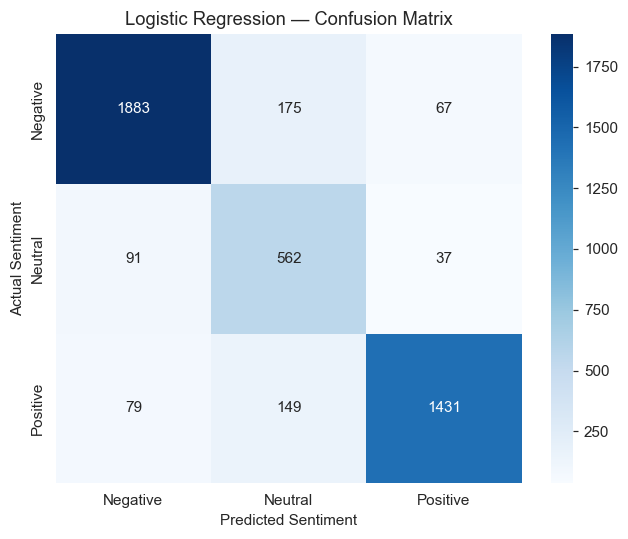

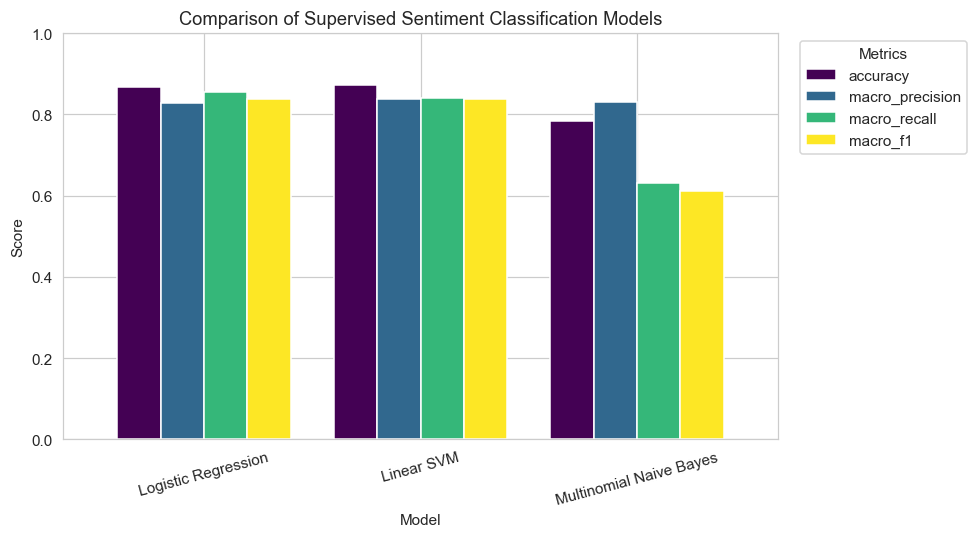

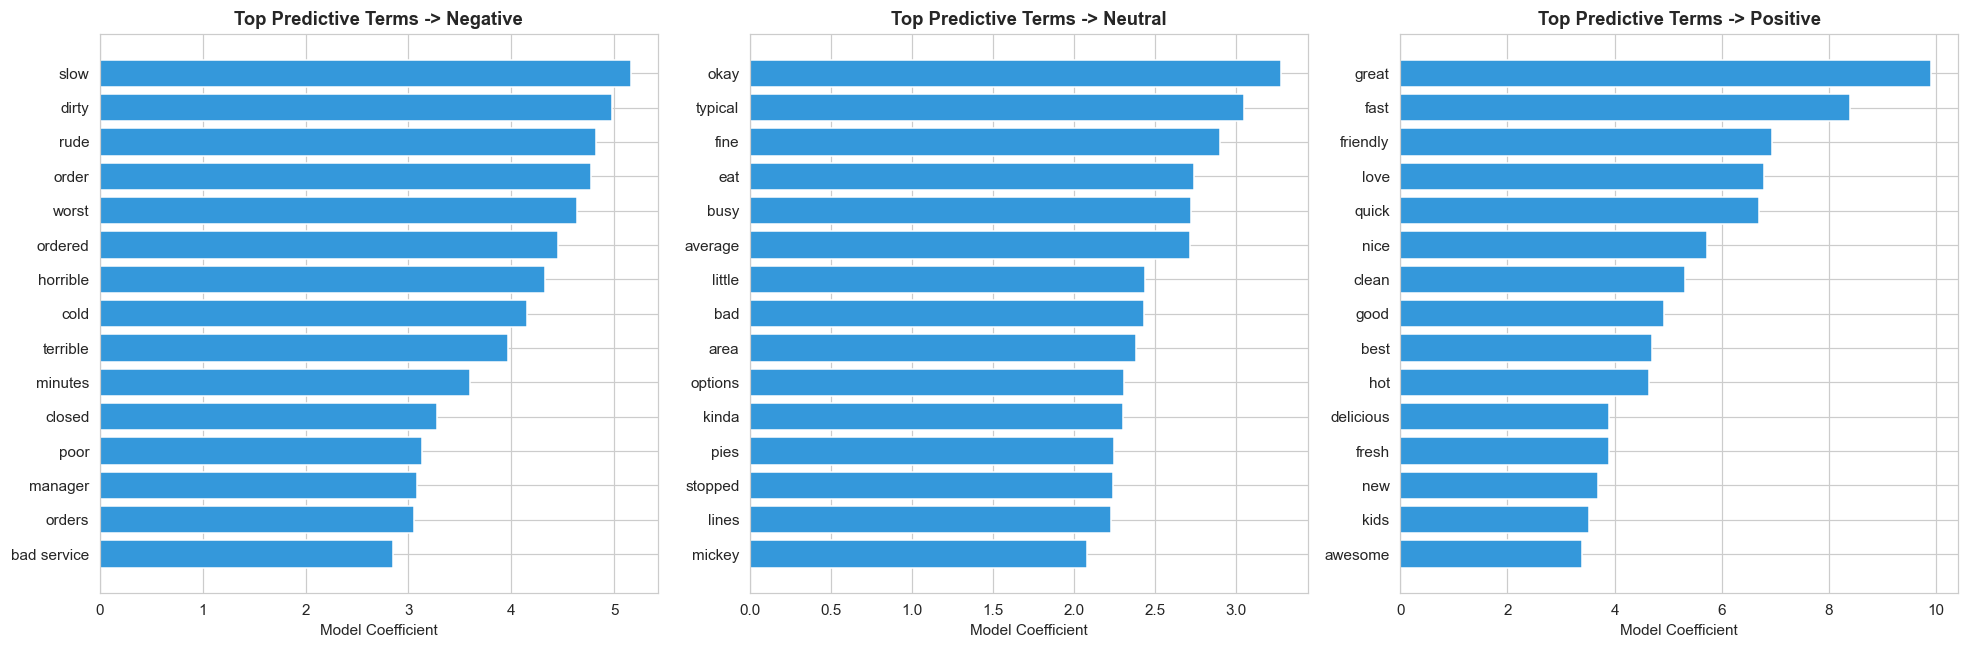

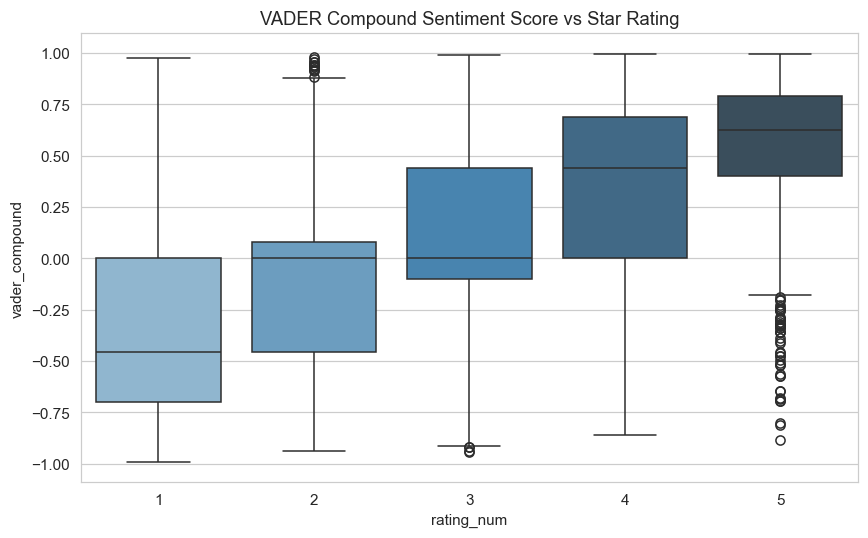

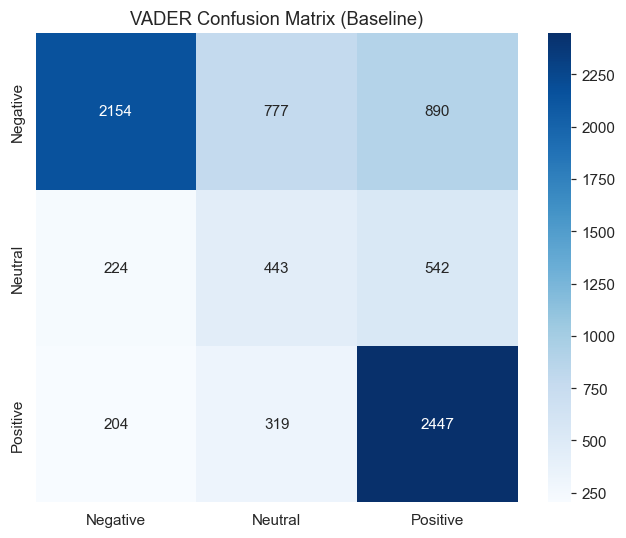


ALL ASSETS SUCCESSFULLY SAVED
Summary JSON: {
  "best_supervised_model": "Linear SVM",
  "best_supervised_accuracy": 0.8722,
  "best_supervised_macro_precision": 0.837,
  "best_supervised_macro_recall": 0.8414,
  "best_supervised_macro_f1": 0.8391,
  "vader_accuracy": 0.6305,
  "vader_macro_precision": 0.5843063223868142,
  "vader_macro_recall": 0.5846836749035408,
  "vader_macro_f1": 0.5699275976240151,
  "n_total": 22366,
  "n_train": 17892,
  "n_test": 4474,
  "tfidf_features": 20000,
  "class_imbalance_handling": "Stratified sampling + class_weight='balanced' cost-sensitive loss",
  "test_size": 0.2,
  "random_state": 42
}


In [1]:
%matplotlib inline
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# ================================================================
# 1. PATH CONFIGURATION
# ================================================================
DATA_PATH = "text_reviews_processed.csv"
RESULTS_DIR = "../results"
MODELS_DIR = "../models"
FIG_DIR = "../Figures"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ================================================================
# 2. LOAD DATA
# ================================================================
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["review_processed"]).copy()

print("=" * 70)
print("DATASET & CLASS IMBALANCE AUDIT")
print("=" * 70)
print(f"Total reviews for modelling: {len(df):,}")
print("\nSentiment class distribution:")
print(df["sentiment"].value_counts())
print("\nClass proportions:")
print(df["sentiment"].value_counts(normalize=True).mul(100).round(2))

# ================================================================
# 3. STRATIFIED TRAIN-TEST SPLIT
# ================================================================
# Stratification is critical for imbalanced classes (Neutral ~14%)
X_text = df["review_processed"].astype(str)
y = df["sentiment"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("STRATIFIED SPLIT (80% TRAIN / 20% TEST)")
print("=" * 70)
print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

# ================================================================
# 4. TF-IDF FEATURE EXTRACTION
# ================================================================
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    min_df=3,
    sublinear_tf=True
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("\n" + "=" * 70)
print("TF-IDF VECTORIZATION")
print("=" * 70)
print(f"Training matrix shape : {X_train_vec.shape}")
print(f"Testing matrix shape  : {X_test_vec.shape}")
print(f"Vocabulary features   : {len(tfidf.get_feature_names_out()):,}")

# ================================================================
# 5. MODEL DEFINITIONS WITH BALANCED WEIGHTING
# ================================================================
# class_weight='balanced' calculates loss penalty w_j = N / (K * n_j)
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),
    "Multinomial Naive Bayes": MultinomialNB()
}

# ================================================================
# 6. TRAIN & EVALUATE MODELS (MACRO-AVERAGED METRICS)
# ================================================================
results = {}
preds_store = {}
classification_reports = {}
order = ["Negative", "Neutral", "Positive"]

print("\n" + "=" * 70)
print("MODEL TRAINING AND BENCHMARKING")
print("=" * 70)

for name, model in models.items():
    print(f"\nTraining: {name}...")
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    preds_store[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )

    results[name] = {
        "accuracy": round(acc, 4),
        "macro_precision": round(prec, 4),
        "macro_recall": round(rec, 4),
        "macro_f1": round(f1, 4)
    }

    rep = classification_report(y_test, y_pred, labels=order, zero_division=0)
    classification_reports[name] = rep
    print(f"{name} -> Accuracy: {acc:.4f} | Macro-F1: {f1:.4f}")

# Select Best Model based on Macro-F1 (fair for imbalanced classes)
results_df = pd.DataFrame(results).T
best_name = results_df["macro_f1"].idxmax()
best_model = models[best_name]
print(f"\n>>> Champion Model Selected by Macro-F1: {best_name}")

# Save Results Table
results_df.to_csv(os.path.join(RESULTS_DIR, "model_results.csv"))

# Save Classification Reports
with open(os.path.join(RESULTS_DIR, "classification_reports.txt"), "w", encoding="utf-8") as f:
    for name, rep in classification_reports.items():
        f.write(f"=== {name} ===\n{rep}\n\n")

# ================================================================
# 7. CONFUSION MATRIX (LOGISTIC REGRESSION)
# ================================================================
cm = confusion_matrix(y_test, preds_store["Logistic Regression"], labels=order)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order, ax=ax)
ax.set_xlabel("Predicted Sentiment")
ax.set_ylabel("Actual Sentiment")
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# ================================================================
# 8. MODEL COMPARISON CHART
# ================================================================
fig, ax = plt.subplots(figsize=(9, 5))
results_df.plot(kind="bar", ax=ax, colormap="viridis", width=0.8)
ax.set_title("Comparison of Supervised Sentiment Classification Models")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metrics", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_model_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

# ================================================================
# 9. LOGISTIC REGRESSION — MOST INFLUENTIAL WORDS
# ================================================================
logreg = models["Logistic Regression"]
feat_names = np.array(tfidf.get_feature_names_out())
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, cls in zip(axes, order):
    idx = list(logreg.classes_).index(cls)
    coefs = logreg.coef_[idx]
    top_idx = np.argsort(coefs)[-15:]
    top_words = feat_names[top_idx]
    top_values = coefs[top_idx]
    ax.barh(top_words, top_values, color="#3498db")
    ax.set_title(f"Top Predictive Terms -> {cls}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Model Coefficient")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_top_predictive_words.png"), dpi=300, bbox_inches="tight")
plt.show()

# ================================================================
# 10. VADER LEXICON-BASED BASELINE
# ================================================================
analyzer = SentimentIntensityAnalyzer()
sample_vader = df.sample(n=min(8000, len(df)), random_state=42).copy()
sample_vader["vader_compound"] = sample_vader["review_clean"].astype(str).apply(
    lambda t: analyzer.polarity_scores(t)["compound"]
)
sample_vader["vader_sentiment"] = sample_vader["vader_compound"].apply(
    lambda c: "Negative" if c <= -0.05 else ("Positive" if c >= 0.05 else "Neutral")
)

v_acc = accuracy_score(sample_vader["sentiment"], sample_vader["vader_sentiment"])
v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
    sample_vader["sentiment"], sample_vader["vader_sentiment"], average="macro", zero_division=0
)

# VADER confusion matrix & boxplot
if "rating_num" in sample_vader.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(data=sample_vader, x="rating_num", y="vader_compound", ax=ax, palette="Blues_d")
    ax.set_title("VADER Compound Sentiment Score vs Star Rating")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "10_vader_vs_rating.png"), dpi=300, bbox_inches="tight")
    plt.show()

vader_cm = confusion_matrix(sample_vader["sentiment"], sample_vader["vader_sentiment"], labels=order)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(vader_cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order, ax=ax)
ax.set_title("VADER Confusion Matrix (Baseline)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "11_vader_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

# Supervised vs VADER Table
comp_table = results_df[["accuracy", "macro_precision", "macro_recall", "macro_f1"]].copy()
comp_table.loc["VADER (Baseline)"] = [round(v_acc, 4), round(v_prec, 4), round(v_rec, 4), round(v_f1, 4)]
comp_table.to_csv(os.path.join(RESULTS_DIR, "supervised_vs_vader.csv"))

# ================================================================
# 11. SAVE MODEL ASSETS & SUMMARY JSON
# ================================================================
joblib.dump(best_model, os.path.join(MODELS_DIR, "best_sentiment_model.pkl"))
joblib.dump(tfidf, os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl"))
joblib.dump(logreg, os.path.join(MODELS_DIR, "logistic_regression_model.pkl"))

summary = {
    "best_supervised_model": best_name,
    "best_supervised_accuracy": float(results_df.loc[best_name, "accuracy"]),
    "best_supervised_macro_precision": float(results_df.loc[best_name, "macro_precision"]),
    "best_supervised_macro_recall": float(results_df.loc[best_name, "macro_recall"]),
    "best_supervised_macro_f1": float(results_df.loc[best_name, "macro_f1"]),
    "vader_accuracy": float(v_acc),
    "vader_macro_precision": float(v_prec),
    "vader_macro_recall": float(v_rec),
    "vader_macro_f1": float(v_f1),
    "n_total": int(len(df)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "tfidf_features": int(len(tfidf.get_feature_names_out())),
    "class_imbalance_handling": "Stratified sampling + class_weight='balanced' cost-sensitive loss",
    "test_size": 0.20,
    "random_state": 42
}

with open(os.path.join(RESULTS_DIR, "summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 70)
print("ALL ASSETS SUCCESSFULLY SAVED")
print("=" * 70)
print("Summary JSON:", json.dumps(summary, indent=2))
